# Portfolio Optimization with VQE (Replication)

This notebook replicates the methodology and implementation of Portfolio Optimization using the Variational Quantum Eigensolver (VQE) with PennyLane, as discussed in the article "Portfolio Optimization with Variational Quantum Eigensolver (VQE) #2".

## 1. Introduction

Portfolio optimization is the process of selecting the best portfolio (asset distribution) aimed at minimizing risk and maximizing return. The Modern Portfolio Theory (MPT) formulation (Markowitz model) is often used, which can be mapped to a Quadratic Unconstrained Binary Optimization (QUBO) problem or an Ising model solvable by quantum algorithms like VQE.

## 2. Mathematical Derivation

### 2.1 Markowitz Model

Let we have $N$ assets. The binary decision variable $x_i \in \{0, 1\}$ indicates whether asset $i$ is included in the portfolio.

The objective is to minimize the variance (risk) minus the expected return, subject to a budget constraint (number of assets to select).

$$ \text{Minimize } \quad w \sum_{i,j} \sigma_{ij} x_i x_j - (1-w) \sum_i \mu_i x_i $$

Where:
- $\sigma_{ij}$ is the covariance between asset $i$ and $j$.
- $\mu_i$ is the expected return of asset $i$.
- $w$ is the risk aversion parameter ($0 \le w \le 1$).

### 2.2 Constraints

We typically enforce a cardinality constraint, meaning we want to select exactly $B$ assets:

$$ \sum_{i=1}^N x_i = B $$

To solve this using VQE (which minimizes an unconstrained Hamiltonian), we add this constraint as a penalty term to the objective function:

$$ P \left( \sum_{i=1}^N x_i - B \right)^2 $$

where $P$ is a large penalty coefficient.

### 2.3 Total Cost Function

The generic cost function becomes:

$$ C(x) = w x^T \Sigma x - (1-w) \mu^T x + P \left( \sum x_i - B \right)^2 $$

### 2.4 Mapping to Ising Hamiltonian

To implement this on a quantum computer (qubits), we map the binary variables $x_i \in \{0, 1\}$ to spin variables $z_i \in \{1, -1\}$ (eigenvalues of Pauli-Z operator) using the transformation:

$$ x_i = \frac{1 - Z_i}{2} $$

Substituting this into the cost function yields the Ising Hamiltonian composed of Pauli-Z operators:

$$ H = \sum_i h_i Z_i + \sum_{i<j} J_{ij} Z_i Z_j + \text{constant} $$

We will construct this Hamiltonian using PennyLane.


In [ ]:
# Install necessary libraries if not present
# !pip install pennylane pandas yfinance matplotlib

In [1]:
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

## 3. Data Preparation

We fetch historical stock data for a set of assets. For this replication, we use a standard set of tech stocks.

In [6]:
tickers = ["AAPL", "GOOGL", "MSFT", "AMZN", "TSLA"] # 5 Assets
start_date = "2020-01-01"
end_date = "2021-01-01"

def get_data(tickers, start, end):
    data = yf.download(tickers, start=start, end=end, auto_adjust=False)['Adj Close']
    return data 

# Fetch data
df = get_data(tickers, start_date, end_date)
print(df.head())

[*********************100%***********************]  5 of 5 completed


Ticker           AAPL       AMZN      GOOGL        MSFT       TSLA
Date                                                              
2020-01-02  72.468262  94.900497  67.920799  152.505661  28.684000
2020-01-03  71.763725  93.748497  67.565491  150.606720  29.534000
2020-01-06  72.335548  95.143997  69.366379  150.996017  30.102667
2020-01-07  71.995369  95.343002  69.232407  149.619293  31.270666
2020-01-08  73.153488  94.598503  69.725174  152.002457  32.809334


In [7]:
# Calculate Daily Returns
returns = df.pct_change().dropna()

# Expected Return (Mean) and Covariance Matrix
mu = returns.mean().to_numpy()
sigma = returns.cov().to_numpy()

print("Expected Returns (mu):", mu)
print("Covariance Matrix (sigma):\n", sigma)

Expected Returns (mu): [0.00272752 0.00243731 0.00127582 0.00171715 0.00997342]
Covariance Matrix (sigma):
 [[0.00086541 0.00049759 0.00053604 0.00068339 0.00078287]
 [0.00049759 0.00058853 0.00039679 0.00049589 0.00062733]
 [0.00053604 0.00039679 0.00058769 0.00057574 0.00061045]
 [0.00068339 0.00049589 0.00057574 0.00076614 0.00078766]
 [0.00078287 0.00062733 0.00061045 0.00078766 0.00317591]]


## 4. Hamiltonian Construction

We need to define the VQE Hamiltonian based on the formula derived above.
We choose parameters:
- $w = 0.5$ (Risk aversion balanced)
- $B = 2$ (Select exactly 2 assets)
- $P = 10$ (Penalty factor)

In [8]:
w = 0.5
B = 2
P = 10.0 # Penalty weight
N = len(tickers)

def build_hamiltonian(mu, sigma, w, B, P):
    coeffs = []
    ops = []
    
    # x_i mapped to (I - Z_i)/2
    # To simplify, we expand the polynomial manually or use coefficients logic.
    # Cost = w * x.T * sigma * x - (1-w) * mu.T * x + P * (sum(x) - B)^2
    
    # Let's compute the matrix Q for QUBO form: x.T * Q * x + linear term
    # The term P(sum x_i - B)^2 = P( (sum x_i)^2 - 2B sum x_i + B^2 )
    # (sum x_i)^2 = sum_i x_i^2 + sum_{i!=j} x_i x_j. Since x_i^2 = x_i for binary, 
    # (sum x_i)^2 = sum_i x_i + sum_{i!=j} x_i x_j.
    
    # Total Linear Coefficient for x_i:
    # From Returns: -(1-w) * mu_i
    # From Variance: w * sigma_ii
    # From Penalty: P * (1 - 2B)
    
    # Total Quadratic Coefficient for x_i x_j (i != j):
    # From Variance: w * sigma_ij + w * sigma_ji = 2 * w * sigma_ij (if symmetric)
    # From Penalty: 2 * P
    
    # Convert QUBO to Ising:
    # x_i -> (I - Z_i)/2
    
    # We will construct the Hamiltonian operator term by term.
    
    # Actually, PennyLane supports constructing Hamiltonians from coefficients and observables.
    # We can perform the substitution x_i = 0.5 * (I - Z_i) symbolically.

    full_hamiltonian = qml.Hamiltonian([], [])
    
    # Loop over all terms to accumulate coefficients for I, Z_i, Z_i Z_j
    
    # Linear terms (x_i)
    for i in range(N):
        coeff_x = -(1-w) * mu[i] + w * sigma[i,i] + P * (1 - 2*B)
        # x_i = 0.5 * I - 0.5 * Z_i
        full_hamiltonian += qml.Hamiltonian([0.5 * coeff_x, -0.5 * coeff_x], [qml.Identity(i), qml.PauliZ(i)])

    # Quadratic terms (x_i x_j)
    for i in range(N):
        for j in range(i+1, N):
            coeff_xx = 2 * w * sigma[i,j] + 2 * P
            # x_i x_j = (0.5 - 0.5 Z_i)(0.5 - 0.5 Z_j) 
            #         = 0.25 (I - Z_i - Z_j + Z_i Z_j)
            
            full_hamiltonian += qml.Hamiltonian(
                [0.25 * coeff_xx, -0.25 * coeff_xx, -0.25 * coeff_xx, 0.25 * coeff_xx],
                [qml.Identity(0), qml.PauliZ(i), qml.PauliZ(j), qml.PauliZ(i) @ qml.PauliZ(j)]
            )
            
    # Constant term from Penalty B^2 (P * B^2)
    full_hamiltonian += qml.Hamiltonian([P * B**2], [qml.Identity(0)])
    
    return full_hamiltonian

H = build_hamiltonian(mu, sigma, w, B, P)
print("Hamiltonian defined with terms:", len(H.ops))

Hamiltonian defined with terms: 51


## 5. Variational Quantum Eigensolver (VQE)

We use a VQE circuit to find the ground state of this Hamiltonian, which corresponds to the optimal portfolio configuration.

### 5.1 Ansatz
We will use a hardware-efficient ansatz (BasicEntanglerLayers).

In [9]:
dev = qml.device("default.qubit", wires=N)

# Define the ansatz
def ansatz(params, wires):
    qml.BasicEntanglerLayers(weights=params, wires=wires)

@qml.qnode(dev)
def cost_function(params):
    ansatz(params, wires=range(N))
    return qml.expval(H)

# Initialize parameter shapes
shape = qml.BasicEntanglerLayers.shape(n_layers=3, n_wires=N)
np.random.seed(0)
params = np.random.random(shape)

### 5.2 Optimization
We use the classical Gradient Descent optimizer to minimize the expectation value.

Step 0: Cost = 22.21345975438586
Step 10: Cost = 5.017575975857994
Step 20: Cost = 5.0028820610341995
Step 30: Cost = 5.0012485352212295
Step 40: Cost = 5.000231097052563
Step 50: Cost = 4.999556610967588
Step 60: Cost = 4.999098098953439
Step 70: Cost = 4.998780731588084
Step 80: Cost = 4.998558152585375
Step 90: Cost = 4.998400531056468
Final Cost: 4.998297726021626


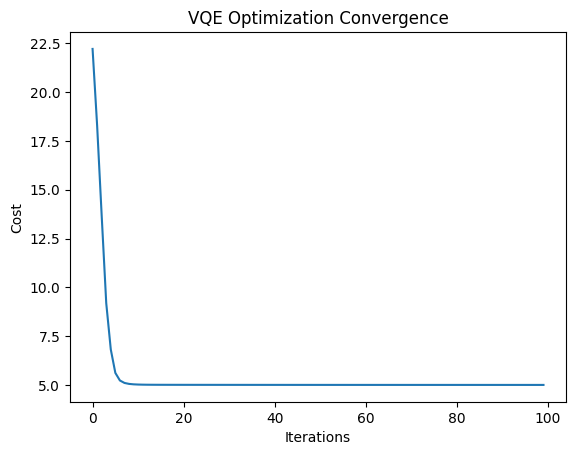

In [10]:
opt = qml.GradientDescentOptimizer(stepsize=0.1)
max_iterations = 100
costs = []

for i in range(max_iterations):
    params, cost = opt.step_and_cost(cost_function, params)
    costs.append(cost)
    if i % 10 == 0:
        print(f"Step {i}: Cost = {cost}")

print(f"Final Cost: {costs[-1]}")

plt.plot(costs)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("VQE Optimization Convergence")
plt.show()

## 6. Results Analysis

To find the optimal portfolio, we sample from the final circuit (or calculate probabilities).

In [11]:
@qml.qnode(dev)
def probability_circuit(params):
    ansatz(params, wires=range(N))
    return qml.probs(wires=range(N))

probs = probability_circuit(params)

# Find state with highest probability
max_prob_idx = np.argmax(probs)
binary_string = format(max_prob_idx, f'0{N}b')

print("Optimal State (Binary):", binary_string)
print("Probability:", probs[max_prob_idx])

selected_assets = [tickers[i] for i, bit in enumerate(binary_string) if bit == '1']
print("Selected Assets:", selected_assets)

Optimal State (Binary): 01001
Probability: 0.21575203030448556
Selected Assets: ['GOOGL', 'TSLA']
